In [20]:
# IMPORTS
import os
import cv2
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Input, Concatenate
from tensorflow.keras.optimizers import Adam

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, cohen_kappa_score, log_loss
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

from sentence_transformers import SentenceTransformer

In [2]:
# RESNET50 FEATURE EXTRACTOR
def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    return Model(inputs=base.input, outputs=base.output)

In [3]:
# SEMANTIC EMBEDDING (GLOVE SUPPORT)
def load_glove(glove_path):
    glove = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            vals = line.split()
            word = vals[0]
            vec = np.array(vals[1:], dtype='float32')
            glove[word] = vec
    return glove


def get_semantic(label, glove=None, dim=100):
    if glove and label in glove:
        return glove[label]
    
    # fallback (deterministic)
    np.random.seed(abs(hash(label)) % (10**6))
    return np.random.rand(dim)

# ====================================================
# ====================================================

# LOAD TRANSFORMER MODEL
def load_semantic_model():
    model = SentenceTransformer('all-MiniLM-L6-v2')
    return model


# GET SEMANTIC EMBEDDING
def get_semantic(label, model):
    emb = model.encode(label)
    return emb

In [4]:
# FEATURE EXTRACTION
def extract_feature(path, model):
    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.resize(img, (224,224))
    x = preprocess_input(np.expand_dims(img,0))
    feat = model.predict(x, verbose=0)[0]

    return feat

In [5]:
# CREATE DATASET CSV
def create_dataset(data_path, sem_model):
    resnet = build_resnet()
    data = []

    for cls in os.listdir(data_path):
        cpath = os.path.join(data_path, cls)

        for img in os.listdir(cpath):
            path = os.path.join(cpath, img)

            feat = extract_feature(path, resnet)
            if feat is None:
                continue

            sem = get_semantic(cls, sem_model)

            data.append((feat, sem, cls, path))

    return data


# def create_dataset(data_path, glove=None):
#     model = build_resnet()
#     data = []

#     for cls in os.listdir(data_path):
#         cpath = os.path.join(data_path, cls)
#         print(f"cpath :{cpath}")

#         for img in os.listdir(cpath):
#             path = os.path.join(cpath, img)
#             print(f"path : {path}")

#             feat = extract_feature(path, model)
#             print(f"feat : {feat}")
#             if feat is None:
#                 continue

#             sem = get_semantic(cls, glove)
#             print(f"sem : {sem}")

#             data.append((feat, sem, cls, path))
            

#     return data

In [6]:
# PREPARE ARRAYS
def prepare_arrays(data):
    X_feat = np.array([d[0] for d in data])
    X_sem = np.array([d[1] for d in data])
    y = np.array([d[2] for d in data])
    paths = np.array([d[3] for d in data])

    return X_feat, X_sem, y, paths

In [7]:
# CONDITIONAL GAN 
# Generator
def build_generator(f_dim, s_dim):
    feat = Input(shape=(f_dim,))
    sem = Input(shape=(s_dim,))

    x = Concatenate()([feat, sem])
    x = Dense(512, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    out = Dense(f_dim)(x)

    return Model([feat, sem], out)


# Discriminator
def build_discriminator(f_dim):
    inp = Input(shape=(f_dim,))
    x = Dense(256, activation='relu')(inp)
    x = Dense(128, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))
    return model


# GAN TRAINING
def train_gan(X_feat, X_sem, epochs=500, batch=32):
    f_dim = X_feat.shape[1]
    s_dim = X_sem.shape[1]

    gen = build_generator(f_dim, s_dim)
    disc = build_discriminator(f_dim)

    # Freeze discriminator for GAN model
    disc.trainable = False

    feat = Input(shape=(f_dim,))
    sem = Input(shape=(s_dim,))
    fake = gen([feat, sem])
    validity = disc(fake)

    gan = Model([feat, sem], validity)
    gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))

    # 📊 History tracking
    history = {
        "d_loss": [],
        "g_loss": []
    }

    for e in range(epochs):

        # ======================
        # SAMPLE REAL DATA
        # ======================
        idx = np.random.randint(0, X_feat.shape[0], batch)
        real = X_feat[idx]
        sem = X_sem[idx]

        # ======================
        # GENERATE FAKE DATA
        # ======================
        # fake = gen.predict([real, sem], verbose=0)
        # Add NOISE properly
        noise = np.random.normal(0,1,(batch, f_dim))
        fake = gen.predict([noise, sem], verbose=0)
        

        # ======================
        # TRAIN DISCRIMINATOR
        # ======================
        disc.trainable = True

        d_loss_real = disc.train_on_batch(real, np.ones((batch,1)))
        d_loss_fake = disc.train_on_batch(fake, np.zeros((batch,1)))

        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        # ======================
        # TRAIN GENERATOR
        # ======================
        disc.trainable = False

        # g_loss = gan.train_on_batch([real, sem], np.ones((batch,1)))
        # Train Generator MORE
        for _ in range(2):
            g_loss = gan.train_on_batch([noise, sem], np.ones((batch,1)))

        # ======================
        # SAVE HISTORY
        # ======================
        history["d_loss"].append(d_loss)
        history["g_loss"].append(g_loss)

        # ======================
        # PRINT LOGS
        # ======================
        if e % 50 == 0:
            print(f"""Epoch {e} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f} | D Real Loss: {d_loss_real:.4f} | D Fake Loss: {d_loss_fake:.4f}""")

    return gen, history


# def train_gan(X_feat, X_sem, epochs=500, batch=32):
#     f_dim = X_feat.shape[1]
#     s_dim = X_sem.shape[1]

#     gen = build_generator(f_dim, s_dim)
#     disc = build_discriminator(f_dim)

#     disc.trainable = False

#     feat = Input(shape=(f_dim,))
#     sem = Input(shape=(s_dim,))
#     fake = gen([feat, sem])
#     validity = disc(fake)

#     gan = Model([feat, sem], validity)
#     gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))

#     for e in range(epochs):
#         idx = np.random.randint(0, X_feat.shape[0], batch)

#         real = X_feat[idx]
#         sem = X_sem[idx]

#         fake = gen.predict([real, sem], verbose=0)

#         disc.trainable = True
#         disc.train_on_batch(real, np.ones((batch,1)))
#         disc.train_on_batch(fake, np.zeros((batch,1)))

#         disc.trainable = False
#         gan.train_on_batch([real, sem], np.ones((batch,1)))

#         if e % 100 == 0:
#             print("Epoch:", e)

#     return gen


# PLOT LOSSES
def plot_gan_losses(history):
    plt.figure()

    # Plot losses
    plt.plot(history["d_loss"], label="Discriminator Loss")
    plt.plot(history["g_loss"], label="Generator Loss")

    # Reference lines
    plt.axhline(y=0.5, linestyle='--', linewidth=1, label='D Ideal (~0.5)')
    plt.axhline(y=1.0, linestyle='--', linewidth=1, label='G Reference (~1.0)')

    # Labels & title
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend()
    plt.show()
    
    
#     plt.figure()
#     plt.plot(history["d_loss"], label="Discriminator Loss")
#     plt.plot(history["g_loss"], label="Generator Loss")

#     plt.legend()
#     plt.title("GAN Training Loss")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.show()

In [8]:
# GENERATE FEATURES (UNSEEN SUPPORT)
def generate_features(gen, labels, sem_model, n=50, f_dim=2048):
    data = []

    for cls in labels:
        sem = get_semantic(cls, sem_model)

        for _ in range(n):
            noise = np.random.normal(0,1,(f_dim,))
            fake = gen.predict([noise.reshape(1,-1), sem.reshape(1,-1)], verbose=0)

            data.append((fake[0], cls))

    X = np.array([d[0] for d in data])
    y = np.array([d[1] for d in data])

    return X, y


# def generate_features(gen, labels, glove=None, n=50, f_dim=2048):
#     data = []

#     for cls in labels:
#         sem = get_semantic(cls, glove)

#         for _ in range(n):
#             noise = np.random.normal(0,1,(f_dim,))
#             fake = gen.predict([noise.reshape(1,-1), sem.reshape(1,-1)], verbose=0)

#             data.append((fake[0], cls))

#     X = np.array([d[0] for d in data])
#     y = np.array([d[1] for d in data])

#     return X, y

In [9]:
# CLASSIFIER
def train_classifier(X, y):
    clf = RandomForestClassifier()
    clf.fit(X, y)
    return clf

In [10]:
# SIMILARITY SEARCH
def similarity_search(query, X, y, paths, top_n=5):
    sims = cosine_similarity([query], X)[0]
    idx = np.argsort(sims)[-top_n:][::-1]

    return [(paths[i], y[i], sims[i]) for i in idx]

In [11]:
# VISUALIZATION
def plot_tsne(X, y):
    tsne = TSNE(n_components=2, random_state=42)
    Xr = tsne.fit_transform(X)

    unique_labels = np.unique(y)
    n_classes = len(unique_labels)

    # Generate distinct colors
    cmap = plt.cm.get_cmap('tab20', n_classes)  # supports up to 20 well
    colors = [cmap(i) for i in range(n_classes)]

    # High-quality figure
    plt.figure(figsize=(10, 7), dpi=300)

    for i, label in enumerate(unique_labels):
        idx = y == label
        plt.scatter(
            Xr[idx, 0],
            Xr[idx, 1],
            color=colors[i],
            label=label,
            alpha=0.7,
            s=20
        )

    # Legend outside (left)
    plt.legend(
        loc='center right',
        bbox_to_anchor=(-0.2, 0.5),
        fontsize=8,
        borderaxespad=0
    )

    plt.title("t-SNE Visualization (Multi-Class)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

    plt.show()


# def plot_tsne(X, y):
#     tsne = TSNE(n_components=2, random_state=42)
#     Xr = tsne.fit_transform(X)
    
#     # High-quality figure (300 DPI)
#     plt.figure(figsize=(8, 6), dpi=300)
#     for label in np.unique(y):
#         i = y == label
#         plt.scatter(Xr[i,0], Xr[i,1], label=label)

#     # Move legend to left outside
#     # plt.legend()
#     plt.legend(
#         loc='center right',
#         bbox_to_anchor=(-0.15, 0.5),  # move to left outside
#         borderaxespad=0
#     )
#     plt.title("t-SNE")
#     # Optional: better layout
#     plt.tight_layout()
#     plt.show()

In [39]:
# PREDICTION
def predict(image_path, resnet, gen, clf, candidate_labels, sem_model):
    feat = extract_feature(image_path, resnet)

    scores = {}

    for label in candidate_labels:
        sem = get_semantic(label, sem_model)

        gen_feat = gen.predict(
            [feat.reshape(1,-1), sem.reshape(1,-1)],
            verbose=0
        )

        prob = clf.predict_proba(gen_feat).max()
        
        scores[label] = prob

    final_pred = max(scores, key=scores.get)

    return final_pred, scores


# def predict(image_path, resnet, gen, clf, candidate_labels, sem_model):
#     feat = extract_feature(image_path, resnet)

#     preds = []

#     for label in candidate_labels:
#         sem = get_semantic(label, sem_model)

#         gen_feat = gen.predict(
#             [feat.reshape(1,-1), sem.reshape(1,-1)],
#             verbose=0
#         )

#         pred = clf.predict(gen_feat)[0]
#         preds.append(pred)

#     # Return most frequent prediction
#     final_pred = max(set(preds), key=preds.count)

#     return final_pred


# def predict(image_path, resnet, gen, clf, label, sem_model):
#     feat = extract_feature(image_path, resnet)
#     sem = get_semantic(label, sem_model)

#     gen_feat = gen.predict([feat.reshape(1,-1), sem.reshape(1,-1)], verbose=0)
#     pred = clf.predict(gen_feat)

#     return pred[0]


# def predict(image_path, resnet, gen, clf, label, glove=None):
#     feat = extract_feature(image_path, resnet)
#     sem = get_semantic(label, glove)

#     gen_feat = gen.predict([feat.reshape(1,-1), sem.reshape(1,-1)], verbose=0)
#     pred = clf.predict(gen_feat)

#     return pred[0]

In [13]:
# =========================
# CONFIG
# =========================
dataset = os.path.join('Trail_balanced_train_class_awa2') # os.path.join('awa_data', 'train') # "dataset/train"
# glove_path = 'glove.6B\\glove.6B.300d.txt' # None   # add path if available
unseen_classes = ['chimpanzee', 'giant_panda', 'hippopotamus', 
                  'humpback_whale', 'leopard', 'persian_cat', 
                  'pig', 'raccoon', 'rat', 'seal']

# =========================
# LOAD TRANSFORMER MODEL
# =========================
print("Loading Transformer semantic model...")
sem_model = load_semantic_model()
print(f"sem_model : {sem_model}")


Loading Transformer semantic model...
sem_model : SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [14]:
# =========================
# STEP 1: DATA
# =========================
print("Extracting features...")
data = create_dataset(dataset, sem_model)
X_feat, X_sem, y, paths = prepare_arrays(data)
X_feat, X_sem, y, paths

Extracting features...




(array([[0.08584143, 1.6857976 , 0.10008364, ..., 0.        , 0.        ,
         0.        ],
        [0.25196773, 2.0854988 , 0.04189356, ..., 0.04259626, 0.        ,
         0.8712754 ],
        [0.11345866, 0.69161564, 0.10036377, ..., 0.3662659 , 0.03667109,
         0.42816225],
        ...,
        [0.27130514, 0.643929  , 0.3655314 , ..., 3.8388236 , 0.18029958,
         0.03418274],
        [0.22993483, 0.16655533, 0.39361715, ..., 0.        , 0.0279413 ,
         0.03532396],
        [0.49702084, 0.        , 1.0899298 , ..., 2.9275908 , 0.38611433,
         0.17649771]], dtype=float32),
 array([[-0.03828095,  0.05772988,  0.05183285, ..., -0.10026271,
          0.00438881, -0.02030399],
        [-0.03828095,  0.05772988,  0.05183285, ..., -0.10026271,
          0.00438881, -0.02030399],
        [-0.03828095,  0.05772988,  0.05183285, ..., -0.10026271,
          0.00438881, -0.02030399],
        ...,
        [ 0.0059095 ,  0.03505268, -0.028708  , ..., -0.03583729,
         

Training cGAN...

Epoch 0 | D Loss: 0.6933 | G Loss: 0.6254 | D Real Loss: 0.6767 | D Fake Loss: 0.7099
Epoch 50 | D Loss: 0.9734 | G Loss: 0.1245 | D Real Loss: 0.0072 | D Fake Loss: 1.9396
Epoch 100 | D Loss: 0.3482 | G Loss: 0.8464 | D Real Loss: 0.0980 | D Fake Loss: 0.5984
Epoch 150 | D Loss: 0.4743 | G Loss: 0.6843 | D Real Loss: 0.2329 | D Fake Loss: 0.7157
Epoch 200 | D Loss: 0.7746 | G Loss: 0.5624 | D Real Loss: 0.6615 | D Fake Loss: 0.8878
Epoch 250 | D Loss: 0.6507 | G Loss: 0.4638 | D Real Loss: 0.2980 | D Fake Loss: 1.0034
Epoch 300 | D Loss: 0.8463 | G Loss: 0.4449 | D Real Loss: 0.6061 | D Fake Loss: 1.0866
Epoch 350 | D Loss: 0.7614 | G Loss: 0.5511 | D Real Loss: 0.5817 | D Fake Loss: 0.9411
Epoch 400 | D Loss: 1.4374 | G Loss: 1.2171 | D Real Loss: 2.5217 | D Fake Loss: 0.3531
Epoch 450 | D Loss: 1.3778 | G Loss: 0.7421 | D Real Loss: 2.1179 | D Fake Loss: 0.6377
gen : <keras.src.engine.functional.Functional object at 0x000002A1621C9720>


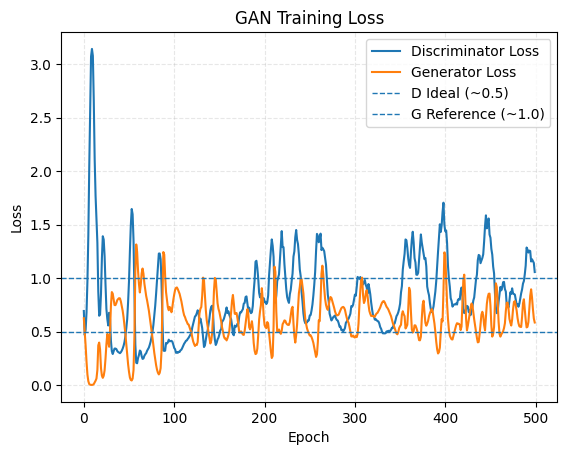

In [15]:
# =========================
# STEP 2: TRAIN GAN
# =========================

'''
What You WANT Ideally
D Loss ≈ 0.5
G Loss ≈ 0.7 – 1.0
'''

print("Training cGAN...")
gen, history = train_gan(X_feat, X_sem, epochs=500, batch=64)
print(f"gen : {gen}")

plot_gan_losses(history)

In [16]:
# =========================
# STEP 3: GENERATE FEATURES
# =========================
print("Generating synthetic features...")
X_fake, y_fake = generate_features(gen, unseen_classes, sem_model)
X_fake, y_fake

Generating synthetic features...


(array([[ 0.7963154 ,  0.38764158, -0.19364396, ...,  0.6153231 ,
          0.260942  ,  0.30786088],
        [ 1.0140295 ,  0.50119615, -0.24711967, ...,  0.76940346,
          0.33707827,  0.41305628],
        [ 0.70744973,  0.35586092, -0.1666744 , ...,  0.54646516,
          0.24565603,  0.28832033],
        ...,
        [ 0.81718224,  0.39978677, -0.19776976, ...,  0.6212817 ,
          0.27497923,  0.32741177],
        [ 1.188047  ,  0.57926893, -0.29530898, ...,  0.89219975,
          0.38716573,  0.48233566],
        [ 0.78801906,  0.38778442, -0.18917927, ...,  0.59936535,
          0.26957014,  0.31350312]], dtype=float32),
 array(['chimpanzee', 'chimpanzee', 'chimpanzee', 'chimpanzee',
        'chimpanzee', 'chimpanzee', 'chimpanzee', 'chimpanzee',
        'chimpanzee', 'chimpanzee', 'chimpanzee', 'chimpanzee',
        'chimpanzee', 'chimpanzee', 'chimpanzee', 'chimpanzee',
        'chimpanzee', 'chimpanzee', 'chimpanzee', 'chimpanzee',
        'chimpanzee', 'chimpanzee', 'c

In [17]:
# =========================
# STEP 4: COMBINE DATA
# =========================
X_all = np.vstack([X_feat, X_fake])
y_all = np.hstack([y, y_fake])
X_all, y_all

(array([[ 0.08584143,  1.6857976 ,  0.10008364, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.25196773,  2.0854988 ,  0.04189356, ...,  0.04259626,
          0.        ,  0.8712754 ],
        [ 0.11345866,  0.69161564,  0.10036377, ...,  0.3662659 ,
          0.03667109,  0.42816225],
        ...,
        [ 0.81718224,  0.39978677, -0.19776976, ...,  0.6212817 ,
          0.27497923,  0.32741177],
        [ 1.188047  ,  0.57926893, -0.29530898, ...,  0.89219975,
          0.38716573,  0.48233566],
        [ 0.78801906,  0.38778442, -0.18917927, ...,  0.59936535,
          0.26957014,  0.31350312]], dtype=float32),
 array(['bear', 'bear', 'bear', ..., 'seal', 'seal', 'seal'], dtype='<U14'))

In [24]:
# =========================
# STEP 5: TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.3,
    random_state=42,
    stratify=y_all   # maintain class distribution
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (6664, 2048)
Test shape: (2856, 2048)


In [27]:
# =========================
# STEP 5: TRAIN CLASSIFIER
# =========================
print("Training classifier...")
# clf = train_classifier(X_all, y_all)
clf = train_classifier(X_train, y_train)
clf

Training classifier...


RandomForestClassifier()

In [31]:
# =========================
# STEP 7: EVALUATE
# =========================
print("Evaluating on test set...")
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Log loss
loss = 1 - acc

# Cohen's Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# Print results
print(f"Accuracy: {acc*100:.2f} %")
print(f"Log Loss: {loss*100:.2f} %")
print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
print("classification_report:")
print(classification_report(y_test, y_pred))

Evaluating on test set...
Accuracy: 87.04 %
Log Loss: 12.96 %
Cohen's Kappa Score: 86.36 %

classification_report:
                precision    recall  f1-score   support

          bear       0.96      0.97      0.96       150
    blue_whale       0.79      0.90      0.84       150
        bobcat       0.92      0.87      0.89       150
    chimpanzee       0.00      0.00      0.00        15
           cow       0.88      0.86      0.87       150
       dolphin       0.81      0.92      0.86       150
   giant_panda       0.00      0.00      0.00        15
       gorilla       0.94      0.99      0.96       150
  hippopotamus       0.08      0.07      0.07        15
humpback_whale       0.11      0.13      0.12        15
  killer_whale       0.87      0.82      0.84       150
       leopard       0.18      0.20      0.19        15
          lion       0.96      0.93      0.95       150
        monkey       0.83      0.87      0.85       150
         mouse       0.88      0.85      0.8


MODEL EVALUATION
Accuracy: 96.11 %
Log Loss: 3.89 %
Cohen's Kappa Score: 95.91 %

classification_report:
                precision    recall  f1-score   support

          bear       0.99      0.99      0.99       500
    blue_whale       0.93      0.97      0.95       500
        bobcat       0.98      0.96      0.97       500
    chimpanzee       0.80      0.70      0.74        50
           cow       0.96      0.96      0.96       500
       dolphin       0.94      0.98      0.96       500
   giant_panda       0.65      0.70      0.67        50
       gorilla       0.98      1.00      0.99       500
  hippopotamus       0.75      0.72      0.73        50
humpback_whale       0.70      0.74      0.72        50
  killer_whale       0.96      0.95      0.95       500
       leopard       0.73      0.76      0.75        50
          lion       0.99      0.98      0.98       500
        monkey       0.95      0.96      0.96       500
         mouse       0.96      0.96      0.96       5

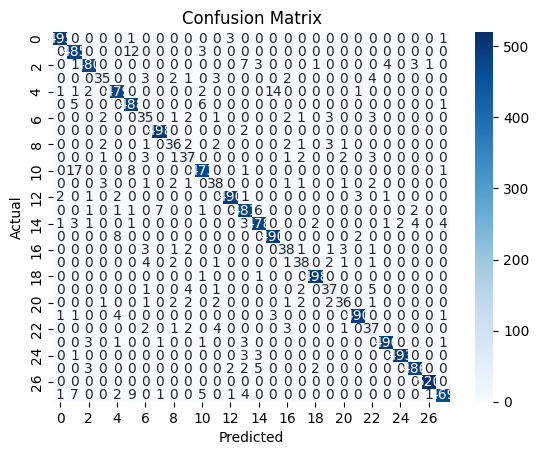

In [33]:
# =========================
# STEP 6: EVALUATE
# =========================
def evaluate_model_final(test_labels, pred_labels):
    '''
    This function is use to model evaluation.
    
    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.
    
    Output: None
    '''
    # Evaluate the model
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc
    
    # AUC-ROC
    # roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr') # .to_numpy().reshape(-1, 1)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    # print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    
# preds = clf.predict(X_feat)
# # print(classification_report(y, preds))
# evaluate_model_final(y, preds)

preds = clf.predict(X_all)
# print(classification_report(y, preds))
evaluate_model_final(y_all, preds)

C:\Users\Kiran\AppData\Local\Temp\ipykernel_14976\1429577443.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_classes)  # supports up to 20 well


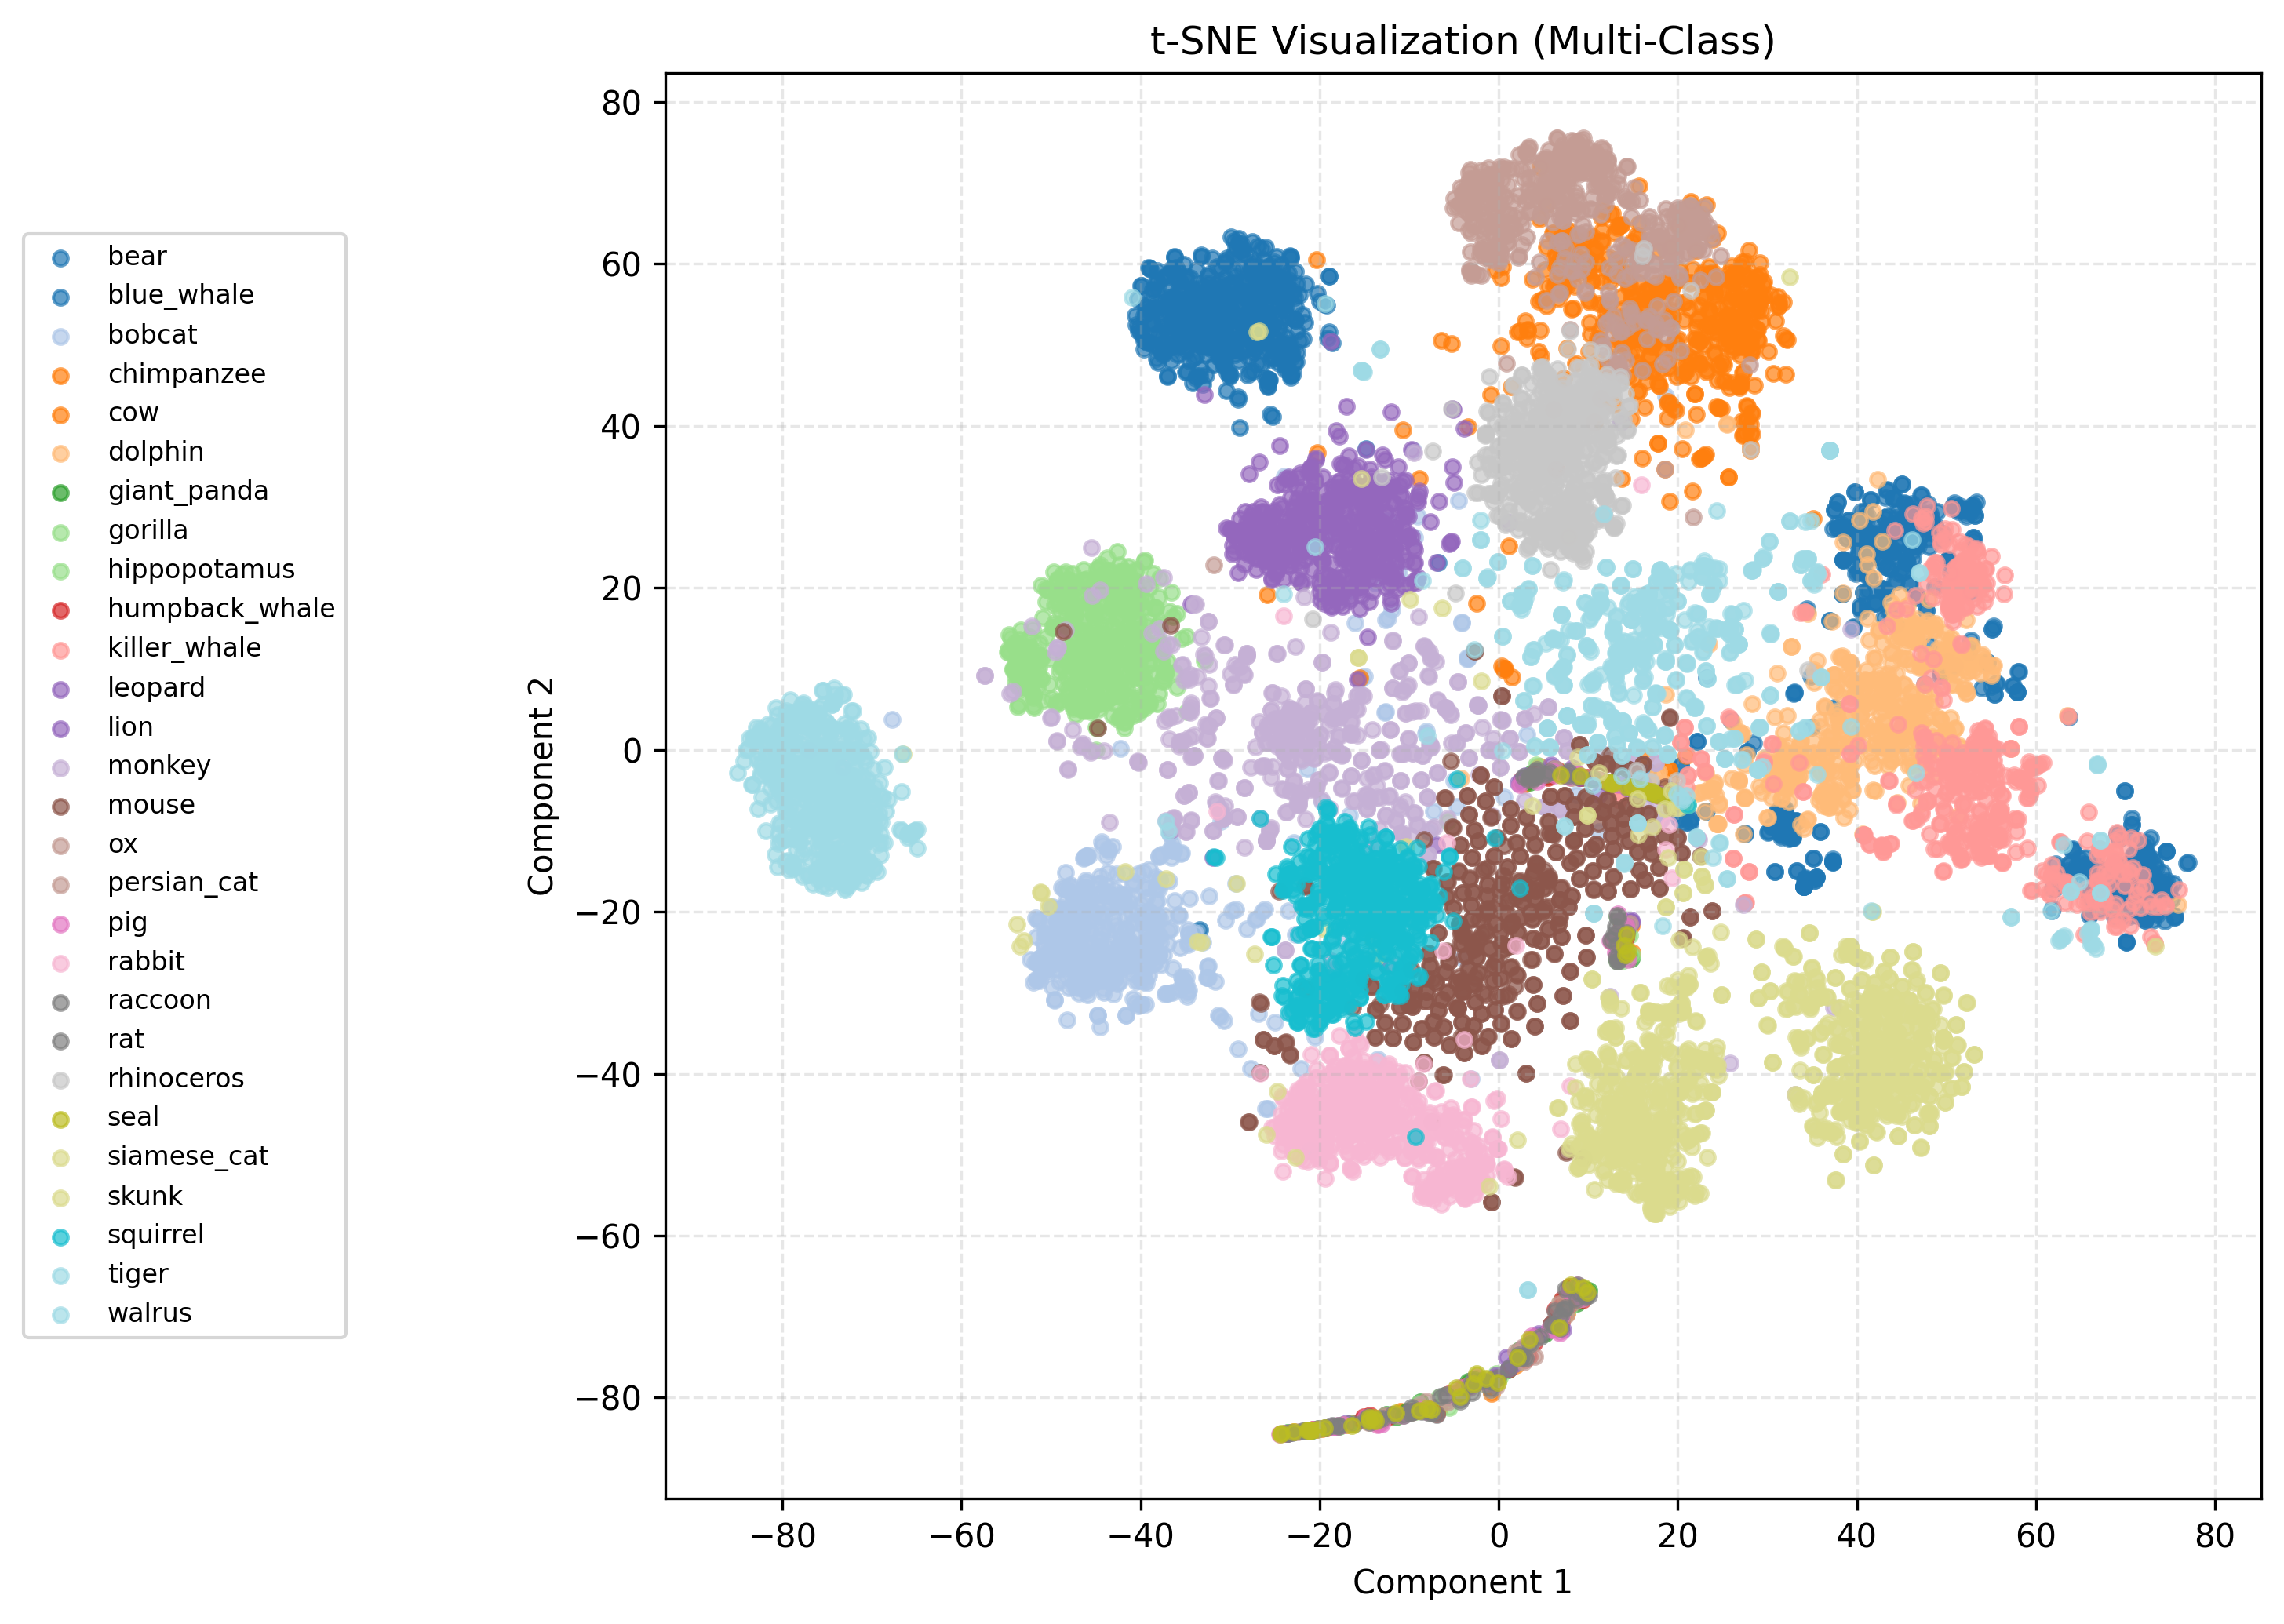

In [35]:
# =========================
# STEP 7: VISUALIZATION
# =========================
plot_tsne(X_all[:], y_all[:])

In [36]:
# =========================
# STEP 8: SAVE MODELS
# =========================
print("Saving models...")
resnet = build_resnet()
resnet.save("resnet.h5")
gen.save("generator.h5")

with open("classifier.pkl","wb") as f:
    pickle.dump(clf, f)

Saving models...


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [40]:
# =========================
# STEP 9: TEST PREDICTION
# =========================
test_img = os.path.join('awa_data', 'test', 'bobcat', 'bobcat_10069.jpg') # change this
# pred = predict(test_img, resnet, gen, clf, unseen_classes[0], glove)
candidate_classes = list(set(y)) + unseen_classes
pred, scores = predict(test_img, resnet, gen, clf, candidate_classes, sem_model)

n = 5
print("Final Prediction:", pred)
print("Scores:", dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n])  )


Final Prediction: rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}


In [43]:
import glob

image_paths, image_names, act_lables, top_seen_labels, top_unseen_labels = [], [], [], [], []
pred_labels, act_vals, pred_vals = [], [], []

candidate_classes = list(set(y)) + unseen_classes
n = 5

for i in glob.glob(os.path.join('awa_data', 'unseen', '*', '*')):
    image_path = i
    image_name = i.split('\\')[-1]
    act_lable = i.split('\\')[-2]
    print(f"image_path : {image_path} \nimage_name : {image_name} \nact_lable : {act_lable}")
    
    pred, scores = predict(test_img, resnet, gen, clf, candidate_classes, sem_model)
    print("pred_label : ", pred)
    print("Scores:", dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]) )
    print("="*100)

    
#     break

image_path : awa_data\unseen\chimpanzee\chimpanzee_10001.jpg 
image_name : chimpanzee_10001.jpg 
act_lable : chimpanzee
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\chimpanzee\chimpanzee_10002.jpg 
image_name : chimpanzee_10002.jpg 
act_lable : chimpanzee
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\chimpanzee\chimpanzee_10003.jpg 
image_name : chimpanzee_10003.jpg 
act_lable : chimpanzee
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\chimpanzee\chimpanzee_10004.jpg 
image_name : chimpanzee_10004.jpg 
act_lable : chimpanzee
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\chimpanzee\chimpanzee_10005.jpg 
im

pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\hippopotamus\hippopotamus_10006.jpg 
image_name : hippopotamus_10006.jpg 
act_lable : hippopotamus
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\hippopotamus\hippopotamus_10007.jpg 
image_name : hippopotamus_10007.jpg 
act_lable : hippopotamus
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\hippopotamus\hippopotamus_10008.jpg 
image_name : hippopotamus_10008.jpg 
act_lable : hippopotamus
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\hippopotamus\hippopotamus_10009.jpg 
image_name : hippopotamus_10009.jpg 
act_lable : hippopotamus
pred_label :  rabbit
Scores: {'r

pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\persian_cat\persian+cat_10001.jpg 
image_name : persian+cat_10001.jpg 
act_lable : persian_cat
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\persian_cat\persian+cat_10002.jpg 
image_name : persian+cat_10002.jpg 
act_lable : persian_cat
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\persian_cat\persian+cat_10003.jpg 
image_name : persian+cat_10003.jpg 
act_lable : persian_cat
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\persian_cat\persian+cat_10004.jpg 
image_name : persian+cat_10004.jpg 
act_lable : persian_cat
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'g

pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\raccoon\raccoon_10007.jpg 
image_name : raccoon_10007.jpg 
act_lable : raccoon
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\raccoon\raccoon_10008.jpg 
image_name : raccoon_10008.jpg 
act_lable : raccoon
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\raccoon\raccoon_10009.jpg 
image_name : raccoon_10009.jpg 
act_lable : raccoon
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5}
image_path : awa_data\unseen\raccoon\raccoon_10010.jpg 
image_name : raccoon_10010.jpg 
act_lable : raccoon
pred_label :  rabbit
Scores: {'rabbit': 0.53, 'gorilla': 0.53, 'blue_whale': 0.51, 'lion': 0.51, 'squirrel': 0.5

In [ ]:
# def main():
#     # =========================
#     # CONFIG
#     # =========================
#     dataset = "dataset/train"
#     unseen_classes = ["tiger", "lion"]

#     # =========================
#     # LOAD TRANSFORMER MODEL
#     # =========================
#     print("Loading Transformer semantic model...")
#     sem_model = load_semantic_model()

#     # =========================
#     # STEP 1: DATA
#     # =========================
#     print("Extracting features...")
#     data = create_dataset(dataset, sem_model)
#     X_feat, X_sem, y, paths = prepare_arrays(data)

#     # =========================
#     # STEP 2: TRAIN GAN
#     # =========================
#     print("Training cGAN...")
#     gen = train_gan(X_feat, X_sem)

#     # =========================
#     # STEP 3: GENERATE FEATURES
#     # =========================
#     print("Generating synthetic features...")
#     X_fake, y_fake = generate_features(gen, unseen_classes, sem_model)

#     # =========================
#     # STEP 4: COMBINE DATA
#     # =========================
#     X_all = np.vstack([X_feat, X_fake])
#     y_all = np.hstack([y, y_fake])

#     # =========================
#     # STEP 5: TRAIN CLASSIFIER
#     # =========================
#     print("Training classifier...")
#     clf = train_classifier(X_all, y_all)

#     # =========================
#     # STEP 6: EVALUATE
#     # =========================
#     preds = clf.predict(X_feat)
#     print(classification_report(y, preds))

#     # =========================
#     # STEP 7: VISUALIZATION
#     # =========================
#     plot_tsne(X_all[:1000], y_all[:1000])

#     # =========================
#     # STEP 8: SAVE MODELS
#     # =========================
#     print("Saving models...")
#     resnet = build_resnet()
#     resnet.save("resnet.h5")
#     gen.save("generator.h5")

#     with open("classifier.pkl","wb") as f:
#         pickle.dump(clf, f)

#     # =========================
#     # STEP 9: TEST
#     # =========================
#     test_img = "test.jpg"
#     pred = predict(test_img, resnet, gen, clf, unseen_classes[0], sem_model)

#     print("Final Prediction:", pred)

In [ ]:
# # MAIN FUNCTION
# def main():
#     # =========================
#     # CONFIG
#     # =========================
#     dataset = os.path.join('awa_data', 'train') # "dataset/train"
#     glove_path = 'glove.6B\\glove.6B.300d.txt' # None   # add path if available
#     unseen_classes = ['chimpanzee', 'giant_panda', 'hippopotamus', 
#                       'humpback_whale', 'leopard', 'persian_cat', 
#                       'pig', 'raccoon', 'rat', 'seal']

#     print("Loading semantic embeddings...")
#     glove = load_glove(glove_path) if glove_path else None

#     # =========================
#     # STEP 1: DATA
#     # =========================
#     print("Extracting features...")
#     data = create_dataset(dataset, glove)
#     X_feat, X_sem, y, paths = prepare_arrays(data)

#     # =========================
#     # STEP 2: TRAIN GAN
#     # =========================
#     print("Training cGAN...")
#     gen = train_gan(X_feat, X_sem)

#     # =========================
#     # STEP 3: GENERATE FEATURES
#     # =========================
#     print("Generating synthetic features...")
#     X_fake, y_fake = generate_features(gen, unseen_classes, glove)

#     # =========================
#     # STEP 4: COMBINE DATA
#     # =========================
#     X_all = np.vstack([X_feat, X_fake])
#     y_all = np.hstack([y, y_fake])

#     # =========================
#     # STEP 5: TRAIN CLASSIFIER
#     # =========================
#     print("Training classifier...")
#     clf = train_classifier(X_all, y_all)

#     # =========================
#     # STEP 6: EVALUATE
#     # =========================
#     preds = clf.predict(X_feat)
#     print(classification_report(y, preds))

#     # =========================
#     # STEP 7: VISUALIZATION
#     # =========================
#     plot_tsne(X_all[:1000], y_all[:1000])  # limit for speed

#     # =========================
#     # STEP 8: SAVE MODELS
#     # =========================
#     print("Saving models...")
#     resnet = build_resnet()
#     resnet.save("resnet.h5")
#     gen.save("generator.h5")

#     with open("classifier.pkl","wb") as f:
#         pickle.dump(clf, f)

#     # =========================
#     # STEP 9: TEST PREDICTION
#     # =========================
#     test_img = os.path.join('awa_data', 'test', 'bobcat', 'bobcat_10069.jpg') # "test.jpg"
#     pred = predict(test_img, resnet, gen, clf, unseen_classes[0], glove)

#     print("Final Prediction:", pred)

#     print("Pipeline Completed ✅")
    

# if __name__ == "__main__":
#     main()